In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]
df = pd.read_csv("../data/KDDTrain.txt", names=columns)

In [3]:
df["binary_label"] = df["label"].apply(lambda x: 0 if x == "normal" else 1)

In [4]:
df = df.drop(columns=[
    "difficulty",
    "label",
    "srv_serror_rate",  
    "dst_host_srv_serror_rate",  
    "srv_rerror_rate",      
    "dst_host_srv_rerror_rate", 
])

In [7]:
categorical_cols = ["protocol_type", "service", "flag"]
encoders = {}
 
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [8]:
X = df.drop(columns=["binary_label"])
y = df["binary_label"]
 
print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature matrix shape: (125973, 37)
Target distribution:
 binary_label
0    67343
1    58630
Name: count, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)
 
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)


Train shape: (100778, 37)
Test shape: (25195, 37)


In [11]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
 
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
y_pred = model.predict(X_test)

In [13]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
 
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print()
print("Full classification report:")
print(classification_report(y_test, y_pred, target_names=["normal", "attack"]))

cm = confusion_matrix(y_test, y_pred)
 
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["normal", "attack"],
            yticklabels=["normal", "attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest Baseline")
plt.savefig("06_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.close()

Accuracy:  0.9979
Precision: 0.9994
Recall:    0.9962
F1 Score:  0.9978

Full classification report:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     13469
      attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



src_bytes                      0.190916
dst_bytes                      0.142747
diff_srv_rate                  0.072886
flag                           0.072250
dst_host_srv_count             0.059690
same_srv_rate                  0.054668
dst_host_same_srv_rate         0.047682
count                          0.046759
dst_host_diff_srv_rate         0.041776
protocol_type                  0.036068
service                        0.033348
logged_in                      0.033059
dst_host_same_src_port_rate    0.028478
dst_host_serror_rate           0.027090
dst_host_srv_diff_host_rate    0.022403
dtype: float64
[[13462     7]
 [   45 11681]]


Text(0.5, 0, 'Importance')

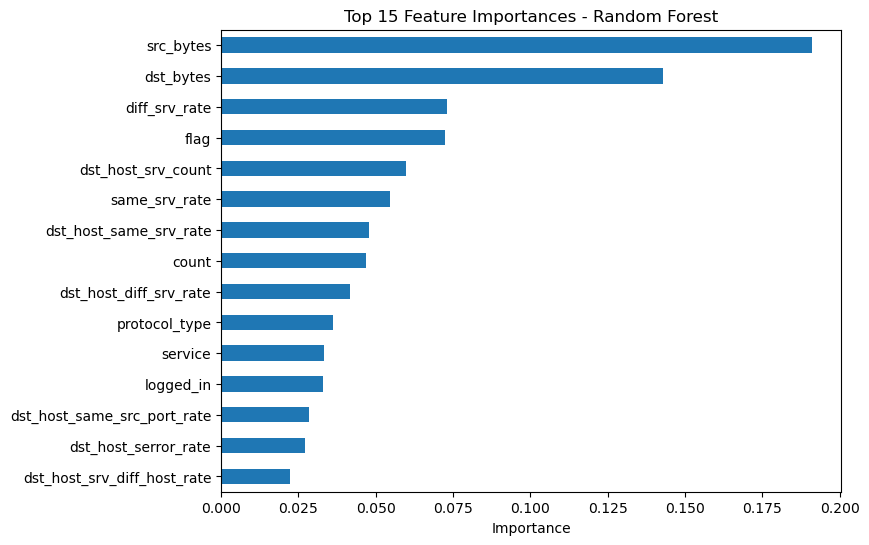

In [18]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)
print(importances) 
print(cm)
plt.figure(figsize=(8,6))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")